In [31]:
import sys
import os

In [32]:
import glob
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [33]:
DATASET_PATH = r"Data Sets\archive\coco128"
IMAGE_PATH = os.path.join(DATASET_PATH, "images", "train2017")
LABEL_PATH = os.path.join(DATASET_PATH, "labels", "train2017")

print("Dataset path :", DATASET_PATH)
print("Image path   :", IMAGE_PATH)
print("Label path   :", LABEL_PATH)

print("\nImages folder exists:", os.path.exists(IMAGE_PATH))
print("Labels folder exists:", os.path.exists(LABEL_PATH))

Dataset path : Data Sets\archive\coco128
Image path   : Data Sets\archive\coco128\images\train2017
Label path   : Data Sets\archive\coco128\labels\train2017

Images folder exists: True
Labels folder exists: True


In [34]:
# count the images and labels
image_files = glob.glob(os.path.join(IMAGE_PATH, "*.jpg"))
label_files = glob.glob(os.path.join(LABEL_PATH, "*.txt"))

print("Number of images :", len(image_files))
print("Number of labels :", len(label_files))

Number of images : 128
Number of labels : 128


In [35]:
# look at the dataset structure
print("Example image files:")
for path in image_files[:5]:
    print(" ", os.path.basename(path))
print("\nExample label files:")
for path in label_files[:5]:
    print(" ", os.path.basename(path))

Example image files:
  000000000009.jpg
  000000000025.jpg
  000000000030.jpg
  000000000034.jpg
  000000000036.jpg

Example label files:
  000000000009.txt
  000000000025.txt
  000000000030.txt
  000000000034.txt
  000000000036.txt


In [36]:
# understand ground truth
# Select a random image
image_file = random.choice(image_files)

image_name = os.path.basename(image_file)
label_file = os.path.join(LABEL_PATH, os.path.splitext(image_name)[0] + ".txt")

print("Image:", image_file)
print("Label:", label_file)

Image: Data Sets\archive\coco128\images\train2017\000000000536.jpg
Label: Data Sets\archive\coco128\labels\train2017\000000000536.txt


Image shape: (336, 448, 3)


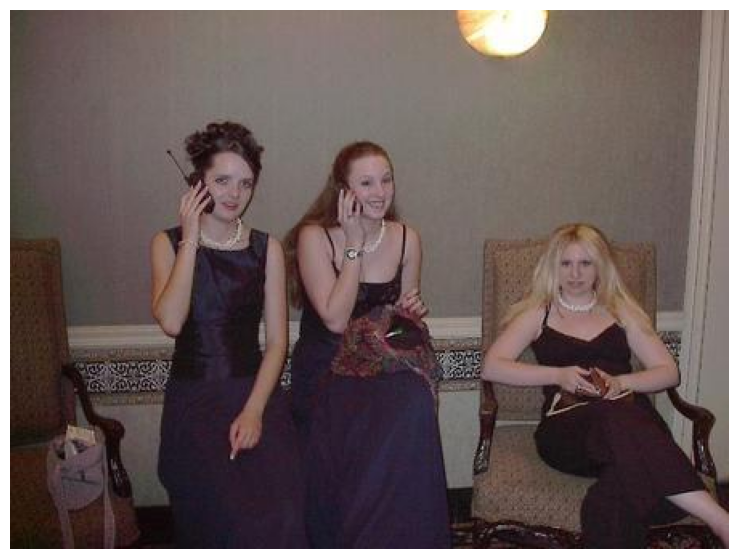

In [37]:
# load and display image
image = cv2.imread(image_file)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print("Image shape:", image.shape)

plt.figure(figsize=(10, 7))
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

In [38]:
# read the yolo annotation
with open(label_file, "r") as f:
    annotations = f.readlines()

print("Number of objects:", len(annotations))

print("\nRaw annotations:")
for line in annotations:
    print(line.strip())

Number of objects: 11

Raw annotations:
56 0.818248 0.704598 0.348951 0.581935
0 0.826853 0.693705 0.346295 0.590089
0 0.499152 0.617054 0.242009 0.760774
0 0.306741 0.59625 0.219107 0.784286
26 0.0984933 0.883988 0.0983259 0.232024
26 0.528594 0.647589 0.155089 0.188155
26 0.818225 0.718661 0.101719 0.0366071
67 0.476049 0.348571 0.0305357 0.0629167
67 0.252422 0.319509 0.0645759 0.117113
56 0.0935714 0.711176 0.184107 0.577649
67 0.815558 0.687158 0.0179464 0.0371131


In [39]:
# understand one annotation
first_annotation = annotations[0].strip().split()

class_id = int(first_annotation[0])
x_center = float(first_annotation[1])
y_center = float(first_annotation[2])
width = float(first_annotation[3])
height = float(first_annotation[4])

print("Class ID :", class_id)
print("X center :", x_center)
print("Y center :", y_center)
print("Width    :", width)
print("Height   :", height)

Class ID : 56
X center : 0.818248
Y center : 0.704598
Width    : 0.348951
Height   : 0.581935


In [40]:
#get image dimensions
image_height, image_width = image.shape[:2]

print("Image width :", image_width)
print("Image height:", image_height)

Image width : 448
Image height: 336


In [41]:
#convert normalized coordinates to pixels
x_center_pixel = x_center * image_width
y_center_pixel = y_center * image_height

box_width_pixel = width * image_width
box_height_pixel = height * image_height

print("Center X:", x_center_pixel)
print("Center Y:", y_center_pixel)
print("Box width:", box_width_pixel)
print("Box height:", box_height_pixel)

Center X: 366.575104
Center Y: 236.744928
Box width: 156.330048
Box height: 195.53016


In [42]:
#convert center coordinates into box corners
x1 = int(x_center_pixel - box_width_pixel / 2)
y1 = int(y_center_pixel - box_height_pixel / 2)

x2 = int(x_center_pixel + box_width_pixel / 2)
y2 = int(y_center_pixel + box_height_pixel / 2)

print("Top-left     :", (x1, y1))
print("Bottom-right :", (x2, y2))

Top-left     : (288, 138)
Bottom-right : (444, 334)


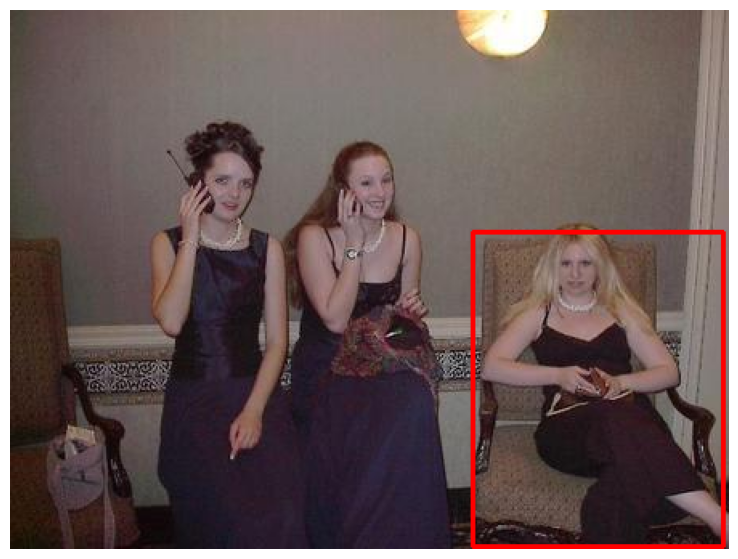

In [43]:
# draw one bounding box
display_image = image_rgb.copy()

cv2.rectangle(
    display_image,
    (x1, y1),
    (x2, y2),
    (255, 0, 0),
    2
)

plt.figure(figsize=(10, 7))
plt.imshow(display_image)
plt.axis("off")
plt.show()

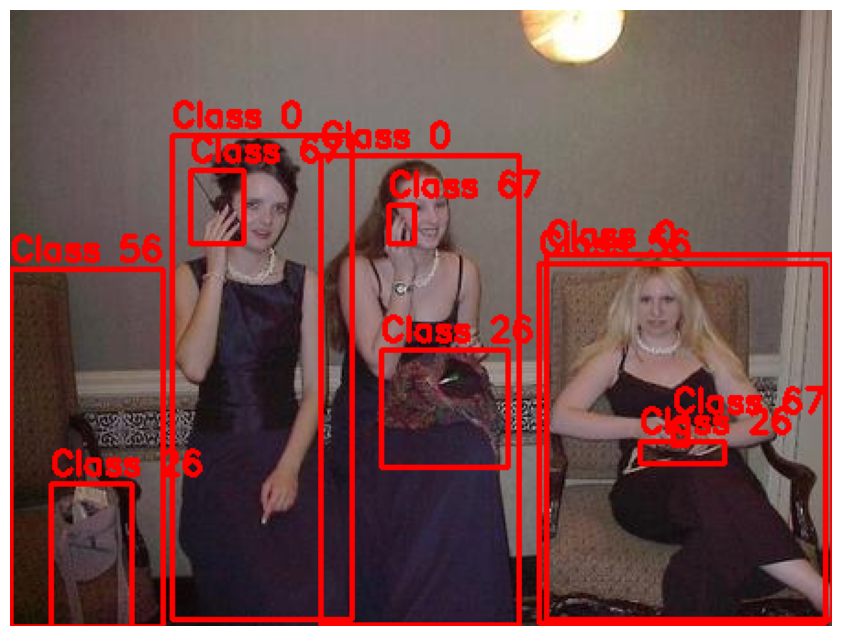

In [44]:
#draw all ground truth boxes
display_image = image_rgb.copy()

for line in annotations:
    values = line.strip().split()

    class_id = int(values[0])
    x_center = float(values[1])
    y_center = float(values[2])
    width = float(values[3])
    height = float(values[4])

    # Convert normalized coordinates to pixels
    xc = x_center * image_width
    yc = y_center * image_height
    w = width * image_width
    h = height * image_height

    # Convert center format to corner format
    x1 = int(xc - w / 2)
    y1 = int(yc - h / 2)
    x2 = int(xc + w / 2)
    y2 = int(yc + h / 2)

    # Draw bounding box
    cv2.rectangle(
        display_image,
        (x1, y1),
        (x2, y2),
        (255, 0, 0),
        2
    )

    # Write class ID
    cv2.putText(
        display_image,
        f"Class {class_id}",
        (x1, max(y1 - 5, 15)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255, 0, 0),
        2
    )

plt.figure(figsize=(12, 8))
plt.imshow(display_image)
plt.axis("off")
plt.show()

In [45]:
#define coco classes
COCO_CLASSES = [
    "person", "bicycle", "car", "motorcycle", "airplane",
    "bus", "train", "truck", "boat", "traffic light",
    "fire hydrant", "stop sign", "parking meter", "bench",
    "bird", "cat", "dog", "horse", "sheep", "cow",
    "elephant", "bear", "zebra", "giraffe", "backpack",
    "umbrella", "handbag", "tie", "suitcase", "frisbee",
    "skis", "snowboard", "sports ball", "kite", "baseball bat",
    "baseball glove", "skateboard", "surfboard", "tennis racket",
    "bottle", "wine glass", "cup", "fork", "knife", "spoon",
    "bowl", "banana", "apple", "sandwich", "orange", "broccoli",
    "carrot", "hot dog", "pizza", "donut", "cake", "chair",
    "couch", "potted plant", "bed", "dining table", "toilet",
    "tv", "laptop", "mouse", "remote", "keyboard", "cell phone",
    "microwave", "oven", "toaster", "sink", "refrigerator",
    "book", "clock", "vase", "scissors", "teddy bear",
    "hair drier", "toothbrush"
]

print("Number of classes:", len(COCO_CLASSES))

Number of classes: 80


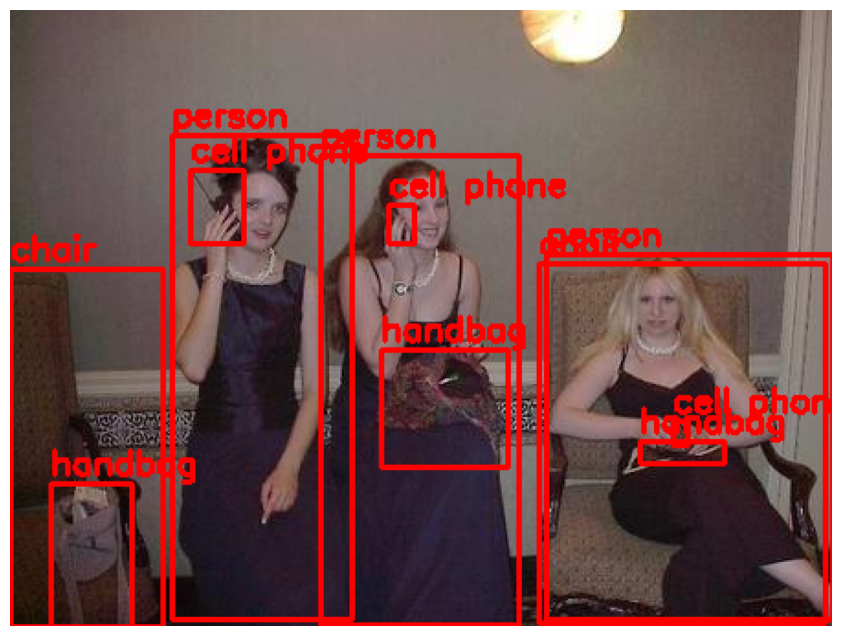

In [46]:
# Display actual class names on the image
display_image = image_rgb.copy()

for line in annotations:
    values = line.strip().split()

    class_id = int(values[0])
    x_center = float(values[1])
    y_center = float(values[2])
    width = float(values[3])
    height = float(values[4])

    xc = x_center * image_width
    yc = y_center * image_height
    w = width * image_width
    h = height * image_height

    x1 = int(xc - w / 2)
    y1 = int(yc - h / 2)
    x2 = int(xc + w / 2)
    y2 = int(yc + h / 2)

    class_name = COCO_CLASSES[class_id]

    cv2.rectangle(display_image, (x1, y1), (x2, y2), (255, 0, 0), 2)

    cv2.putText(
        display_image,
        class_name,
        (x1, max(y1 - 5, 15)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255, 0, 0),
        2
    )

plt.figure(figsize=(12, 8))
plt.imshow(display_image)
plt.axis("off")
plt.show()

In [48]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.7 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\SUYASH\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [49]:
# load a pretrained yolo model
model = YOLO("yolo11n.pt")
print("Model loaded successfully")

Model loaded successfully


In [50]:
# run yolo on our image
results = model(image_file)
print("Detection Completed.")


image 1/1 e:\Pyhton code\Data Sets\archive\coco128\images\train2017\000000000536.jpg: 480x640 3 persons, 1 handbag, 1 chair, 98.7ms
Speed: 78.1ms preprocess, 98.7ms inference, 47.9ms postprocess per image at shape (1, 3, 480, 640)
Detection Completed.


In [51]:
result = results[0]
print(result)

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
depth: None
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'po

In [52]:
# inspect bounding boxes
boxes = result.boxes
print(boxes)

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([ 0.,  0.,  0., 26., 56.], device='cuda:0')
conf: tensor([0.9370, 0.9047, 0.8910, 0.4244, 0.3937], device='cuda:0')
data: tensor([[2.9177e+02, 1.3323e+02, 4.4771e+02, 3.3600e+02, 9.3695e-01, 0.0000e+00],
        [1.7358e+02, 8.0184e+01, 2.7475e+02, 3.3565e+02, 9.0469e-01, 0.0000e+00],
        [8.6709e+01, 6.8045e+01, 1.8425e+02, 3.3535e+02, 8.9097e-01, 0.0000e+00],
        [2.1677e+01, 2.2063e+02, 8.1520e+01, 3.3596e+02, 4.2435e-01, 2.6000e+01],
        [2.9226e+02, 1.4083e+02, 4.3342e+02, 3.3274e+02, 3.9365e-01, 5.6000e+01]], device='cuda:0')
id: None
is_track: False
orig_shape: (336, 448)
shape: torch.Size([5, 6])
xywh: tensor([[369.7408, 234.6163, 155.9420, 202.7673],
        [224.1679, 207.9184, 101.1665, 255.4683],
        [135.4810, 201.6997,  97.5433, 267.3093],
        [ 51.5981, 278.2921,  59.8429, 115.3268],
        [362.8393, 236.7868, 141.1583, 191.9079]], device='cuda:0')
xywhn: tensor([[0.8253, 0.6983, 

In [53]:
#Get class IDs and confidence scores
class_ids = boxes.cls.cpu().numpy()
confidences = boxes.conf.cpu().numpy()

print("Class IDs:")
print(class_ids)

print("\nConfidence scores:")
print(confidences)

Class IDs:
[          0           0           0          26          56]

Confidence scores:
[    0.93695     0.90469     0.89097     0.42435     0.39365]


In [54]:
#inspect predicted coordinates
xyxy = boxes.xyxy.cpu().numpy()

print("Bounding boxes:")
print(xyxy)

Bounding boxes:
[[     291.77      133.23      447.71         336]
 [     173.58      80.184      274.75      335.65]
 [     86.709      68.045      184.25      335.35]
 [     21.677      220.63       81.52      335.96]
 [     292.26      140.83      433.42      332.74]]


In [55]:
#display detection properly
for class_id, confidence, box in zip(class_ids, confidences, xyxy):

    class_id = int(class_id)
    class_name = COCO_CLASSES[class_id]

    x1, y1, x2, y2 = box.astype(int)

    print(
        f"{class_name:15s} "
        f"confidence={confidence:.2f} "
        f"box=({x1}, {y1}, {x2}, {y2})"
    )

person          confidence=0.94 box=(291, 133, 447, 336)
person          confidence=0.90 box=(173, 80, 274, 335)
person          confidence=0.89 box=(86, 68, 184, 335)
handbag         confidence=0.42 box=(21, 220, 81, 335)
chair           confidence=0.39 box=(292, 140, 433, 332)


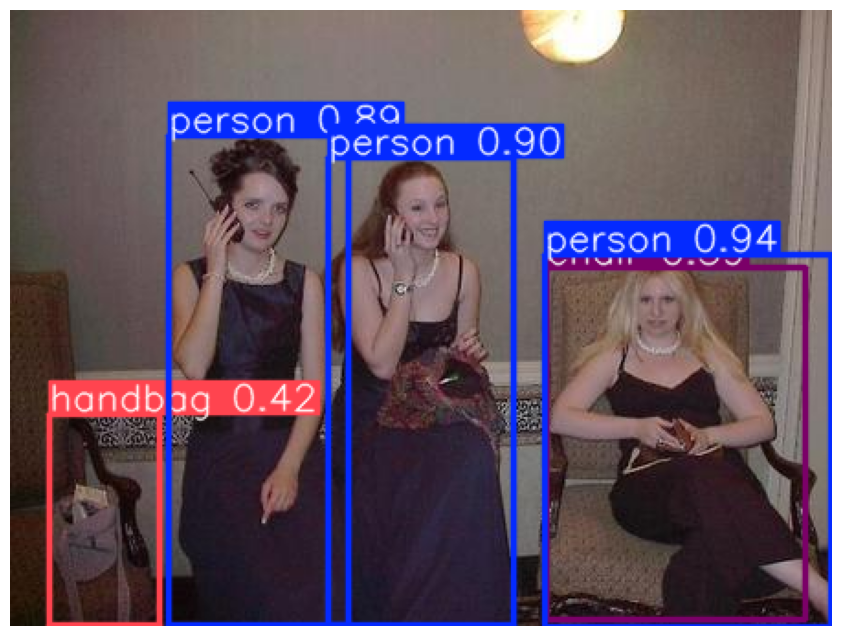

In [56]:
# yolo prediction
annotated_image = result.plot()

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [57]:
# run yolo with different confidence thresholds
confidence_levels = [0.25, 0.50, 0.75]

for conf in confidence_levels:

    results_threshold = model(
        image_file,
        conf=conf,
        verbose=False
    )

    result_threshold = results_threshold[0]

    print(
        f"Confidence threshold = {conf} | "
        f"Detections = {len(result_threshold.boxes)}"
    )

Confidence threshold = 0.25 | Detections = 5
Confidence threshold = 0.5 | Detections = 3
Confidence threshold = 0.75 | Detections = 3


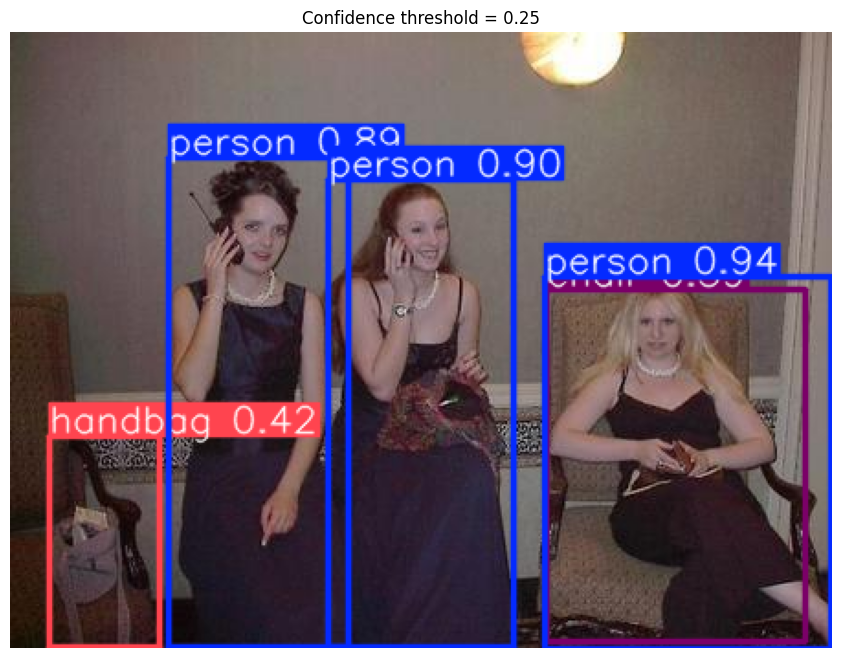

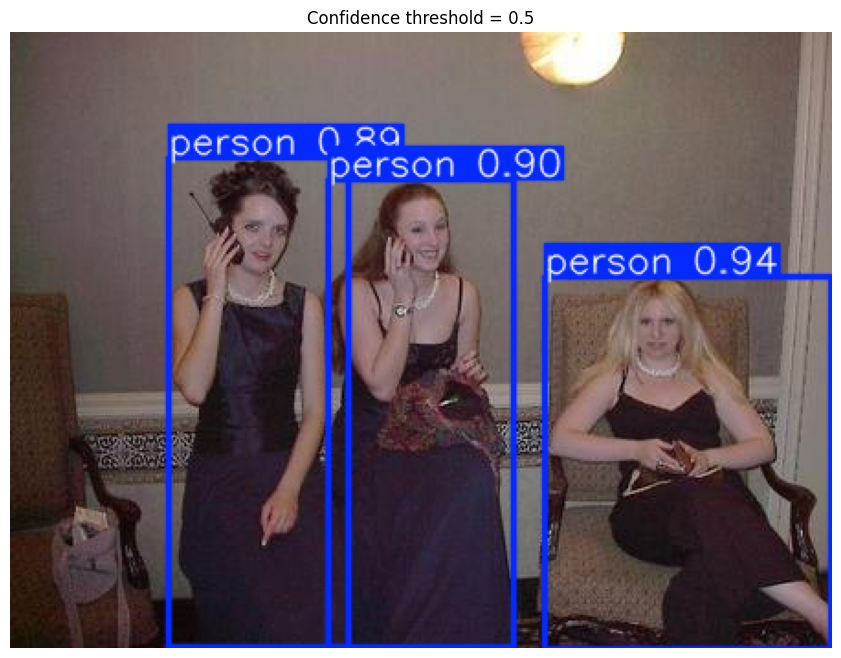

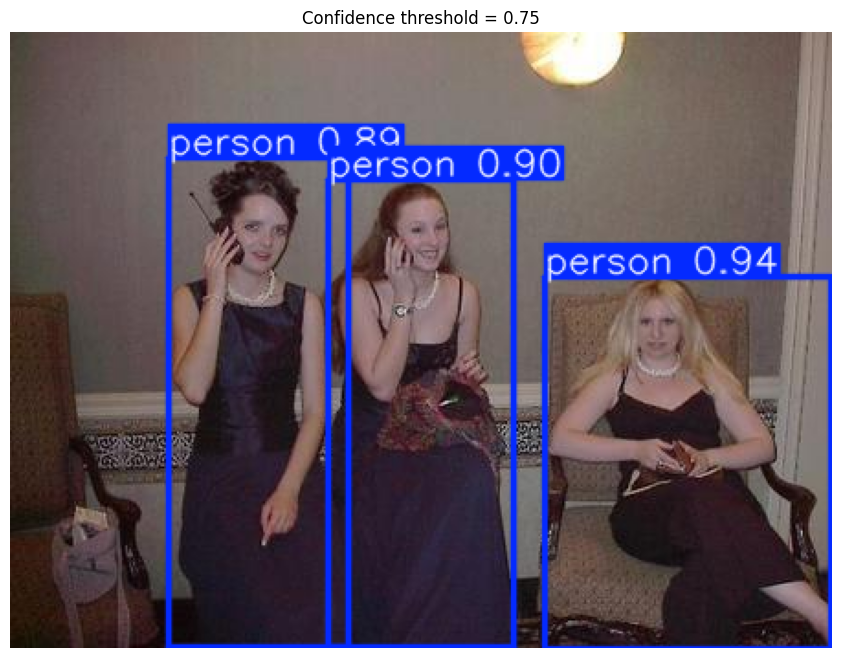

In [58]:
# compare thresholds visually
for conf in confidence_levels:

    results_threshold = model(
        image_file,
        conf=conf,
        verbose=False
    )

    annotated = results_threshold[0].plot()

    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.title(f"Confidence threshold = {conf}")
    plt.axis("off")
    plt.show()

In [59]:
# create an IoU function
def calculate_iou(box1, box2):

    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])

    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection_width = max(0, x2 - x1)
    intersection_height = max(0, y2 - y1)

    intersection_area = (
        intersection_width * intersection_height
    )

    area1 = (
        (box1[2] - box1[0]) *
        (box1[3] - box1[1])
    )

    area2 = (
        (box2[2] - box2[0]) *
        (box2[3] - box2[1])
    )

    union_area = area1 + area2 - intersection_area

    if union_area == 0:
        return 0

    return intersection_area / union_area


print("IoU function created.")

IoU function created.


In [60]:
# test iou
box_a = [100, 100, 300, 300]
box_b = [150, 150, 350, 350]

iou = calculate_iou(box_a, box_b)

print("IoU:", iou)

IoU: 0.391304347826087


In [61]:
# test the model n several images
sample_images = random.sample(image_files, min(5, len(image_files)))

for img_path in sample_images:

    results = model(img_path, verbose=False)

    result = results[0]

    print(
        os.path.basename(img_path),
        "→",
        len(result.boxes),
        "detections"
    )

000000000531.jpg → 10 detections
000000000360.jpg → 1 detections
000000000109.jpg → 9 detections
000000000623.jpg → 3 detections
000000000192.jpg → 4 detections


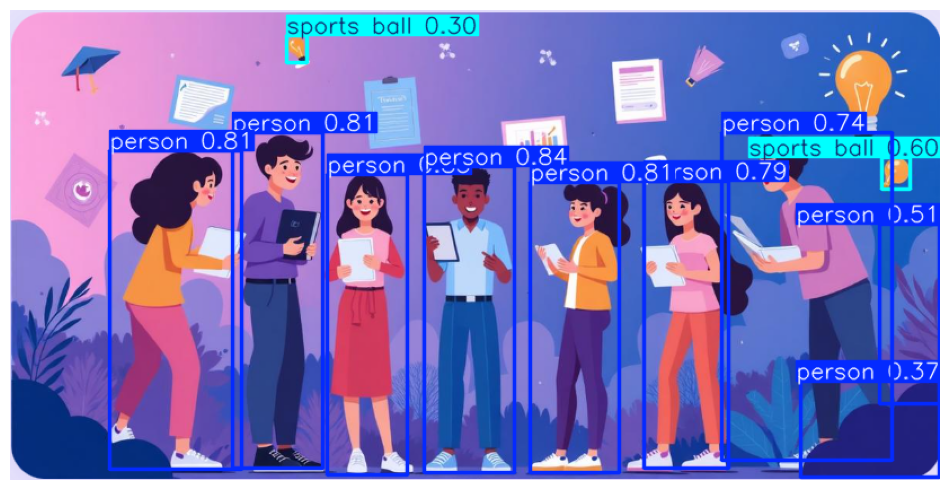

In [64]:
#detect object in your own image
MY_IMAGE = r"C:\Users\SUYASH\OneDrive\Pictures\Screenshots\Screenshot 2026-01-17 160741.png"
results = model(MY_IMAGE, verbose=False)

annotated = results[0].plot()

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

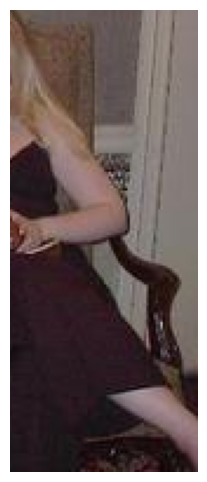

In [65]:
# crop a detected object
result = results[0]

if len(result.boxes) > 0:

    # Take the first detected object
    box = result.boxes.xyxy[0].cpu().numpy().astype(int)

    x1, y1, x2, y2 = box

    cropped_object = image_rgb[y1:y2, x1:x2]

    plt.figure(figsize=(6, 6))
    plt.imshow(cropped_object)
    plt.axis("off")
    plt.show()

else:
    print("No objects detected.")